In [1]:
# Business Understanding

# Companies need to predict customer behaviour to reduce risk and prevent losses.

# In this project, we use the German Credit Dataset to classify customers as high or low risk.

# We test two models:
# - Logistic Regression (simple baseline model)
# - Random Forest (more complex model)

# The goal is to compare model performance and choose the best one for business use.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [4]:
df = pd.read_csv(r"C:\Users\USER\Downloads\german_credit_with_headers.csv")
df.tail()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,NumberExistingCredits,Job,LiablePeople,Telephone,ForeignWorker,Risk
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,...,A123,27,A143,A152,1,A173,1,A191,A201,1


In [5]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Status                 1000 non-null   str  
 1   Duration               1000 non-null   int64
 2   CreditHistory          1000 non-null   str  
 3   Purpose                1000 non-null   str  
 4   CreditAmount           1000 non-null   int64
 5   Savings                1000 non-null   str  
 6   Employment             1000 non-null   str  
 7   InstallmentRate        1000 non-null   int64
 8   PersonalStatusSex      1000 non-null   str  
 9   OtherDebtors           1000 non-null   str  
 10  ResidenceDuration      1000 non-null   int64
 11  Property               1000 non-null   str  
 12  Age                    1000 non-null   int64
 13  OtherInstallmentPlans  1000 non-null   str  
 14  Housing                1000 non-null   str  
 15  NumberExistingCredits  1000 non-null   int64
 16  

(1000, 21)

In [6]:
df.isnull().sum()

Status                   0
Duration                 0
CreditHistory            0
Purpose                  0
CreditAmount             0
Savings                  0
Employment               0
InstallmentRate          0
PersonalStatusSex        0
OtherDebtors             0
ResidenceDuration        0
Property                 0
Age                      0
OtherInstallmentPlans    0
Housing                  0
NumberExistingCredits    0
Job                      0
LiablePeople             0
Telephone                0
ForeignWorker            0
Risk                     0
dtype: int64

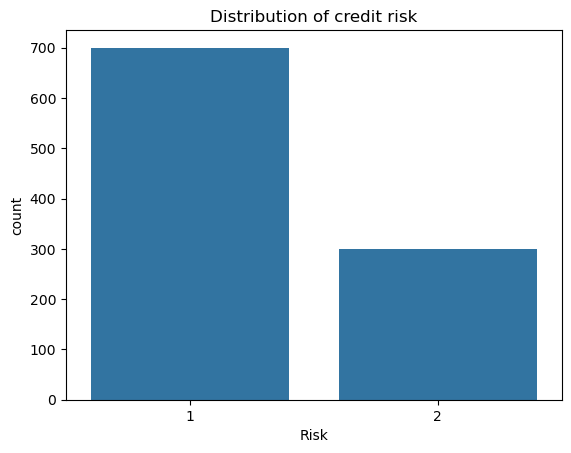

In [7]:
# EDA(Exploratory Data Analysis)
sns.countplot(x='Risk', data=df)
plt.title("Distribution of credit risk")
plt.show()

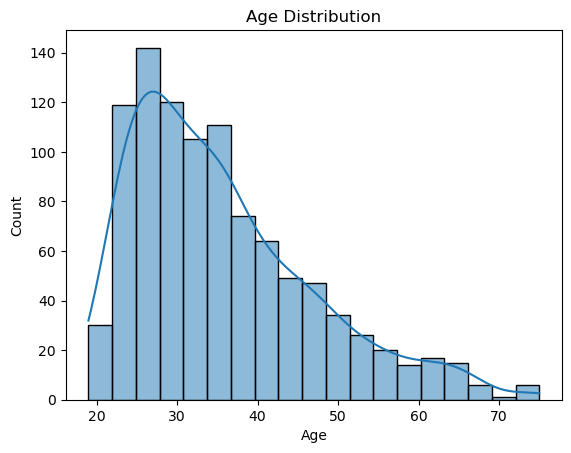

In [8]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [20]:
# Encoding Data
encoder = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = encoder.fit_transform(df[col])

In [26]:
#Splitting our data(Training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
#Scaling our Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
#DEFINING OF OUR VARIABLES/ Feature selection
X = df.drop('Risk', axis=1)
y = df['Risk']

In [29]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print(y_pred_log[:10])

[1 2 2 1 1 1 1 1 1 1]


In [40]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
y_pred_rf = rf_model.predict(X_test)
print(y_pred_rf[:10])

[1 1 2 1 1 1 1 1 1 1]


In [35]:
y_pred_log = log_model.predict(X_test)

print(y_pred_log[:10])

[1 2 2 1 1 1 1 1 1 1]


In [44]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf)
print("Confusion Matrix(Random Forest)")
print (cm_rf)

Confusion Matrix(Random Forest)
[[131  10]
 [ 29  30]]


In [62]:
cm_log = confusion_matrix(y_test, y_pred_log)

In [63]:
print("Confusion Matrix (Logistic Regression):")
print(cm_log)

Confusion Matrix (Logistic Regression):
[[126  15]
 [ 30  29]]


In [64]:
log_acc = accuracy_score(
    y_test,
    log_preds)

rf_acc = accuracy_score(
    y_test,
    rf_preds)

In [45]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           1       0.81      0.89      0.85       141
           2       0.66      0.49      0.56        59

    accuracy                           0.78       200
   macro avg       0.73      0.69      0.71       200
weighted avg       0.76      0.78      0.76       200

Accuracy: 0.775


In [46]:
print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

RANDOM FOREST
              precision    recall  f1-score   support

           1       0.82      0.93      0.87       141
           2       0.75      0.51      0.61        59

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200

Accuracy: 0.805


In [51]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False)

print(feature_importance)

                  Feature  Importance
4            CreditAmount    0.131240
12                    Age    0.104386
0                  Status    0.103118
1                Duration    0.095828
3                 Purpose    0.066581
2           CreditHistory    0.061481
6              Employment    0.055956
5                 Savings    0.049017
11               Property    0.047091
10      ResidenceDuration    0.043563
7         InstallmentRate    0.042611
8       PersonalStatusSex    0.033586
16                    Job    0.032321
14                Housing    0.028624
13  OtherInstallmentPlans    0.026188
15  NumberExistingCredits    0.020973
18              Telephone    0.020619
9            OtherDebtors    0.018796
17           LiablePeople    0.013886
19          ForeignWorker    0.004134


In [47]:
#EVALUATION OF THE MODELS:Random Forest is best as it carries a better accuracy and precision score